In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
The CIAO setup for this window has changed from
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3
To:
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
if test x`uname` = xDarwin
then
  export CC=/opt/local/bin/gcc
fi

echo | install_marx `pwd`  < /dev/null


Installing MARX 5.3.2 into /data/sdsreg/thread_output/CIAO4.9/srcextent

If this is not where you want it installed, please
press Control+C to exit and specify the directory.

Press Enter to continue
--2017-01-11 10:43:46--  ftp://space.mit.edu/pub/cxc/marx/v5.3/marx-dist-5.3.2.tar.gz
           => `marx-dist-5.3.2.tar.gz'
Resolving space.mit.edu... 18.75.0.10
Connecting to space.mit.edu|18.75.0.10|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /pub/cxc/marx/v5.3 ... done.
==> SIZE marx-dist-5.3.2.tar.gz ... 13500024
==> PASV ... done.    ==> RETR marx-dist-5.3.2.tar.gz ... done.
Length: 13500024 (13M) (unauthoritative)

100%[======================================>] 13,500,024  4.85M/s   in 2.7s    

2017-01-11 10:43:49 (4.85 MB/s) - `marx-dist-5.3.2.tar.gz' saved [13500024]

checking for gcc... gcc
checking whether the C compiler works... yes
checking for C compiler default output file name... a.out
ch

In [3]:
source marx-5.3.2/setup_marx.sh 

In [4]:
/bin/rm -rf 4425
download_chandra_obsid 4425 evt1,bpix,bias,pbk,mtl,msk,fov,asol,stat,flt



  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  bpix     fits        4 Kb  ####################          < 1 s  759.5 kb/s
  fov      fits        5 Kb  ####################          < 1 s  827.2 kb/s
  asol     fits       10 Mb  ####################          < 1 s  71765.4 kb/s
  evt1     fits        3 Mb  ####################          < 1 s  71157.3 kb/s
  flt      fits        5 Kb  ####################          < 1 s  777.3 kb/s
  msk      fits        4 Kb  ####################          < 1 s  497.7 kb/s
  mtl      fits        8 Mb  ####################          < 1 s  68375.5 kb/s
  stat     fits        1 Mb  ####################          < 1 s  50944.4 kb/s
  bias     fits       71 Kb  ####################          < 1 s  7671.1 kb/s
  pbk      fits        4 Kb  ####################          < 1 s  663.1 kb/s

      Total download size for ObsId 4425 = 22 Mb
      Total do

In [5]:
chandra_repro 4425 out=`pwd` clob+


Processing input directory '/data/sdsreg/thread_output/CIAO4.9/srcextent/4425'

Resetting afterglow status bits in evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create a new bad pixel file...

Running acis_process_events to reprocess the evt1.fits file...
Filtering the evt1.fits file by grade and status and time...
Applying the good time intervals from the flt1.fits file...
The new evt2.fits file is: /data/sdsreg/thread_output/CIAO4.9/srcextent/acisf04425_repro_evt2.fits

Updating the event file header with chandra_repro HISTORY record
Creating FOV file...
Setting observation-specific bad pixel file in local ardlib.par.

Cleaning up intermediate files

         /data/sdsreg/thread_output/CIAO4.9/srcextent/acisf04425_repro_bpix1.fits
         Run 'punlearn ardlib' when analysis of this dataset completed.

The data have been reprocessed.
Start your analysis with the new products in
/data/sdsreg/thread_output/CIAO4.9/srcextent



In [6]:
cat << EOM > src.reg
# Region file format: CIAO version 1.0
circle(4048.0442,4044.9091,10)
EOM


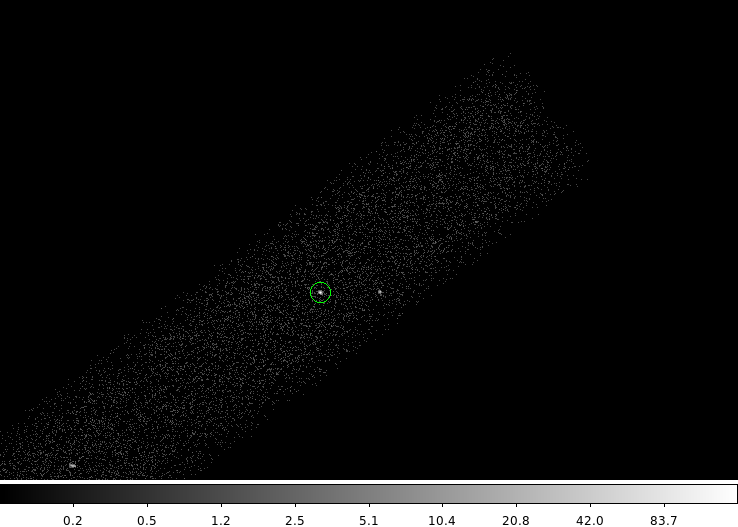

In [7]:
ds9 acisf04425_repro_evt2.fits -scale log \
  -bin factor 1 \
  -region src.reg \
  -saveimage png ds9_01.png -quit

display < ds9_01.png

## Simulate psf

In [8]:
punlearn dmcoords
dmcoords acisf04425_repro_evt2.fits op=sky x=4048.0442 y=4044.9091 celfmt=deg verb=0
ra=`pget dmcoords ra`
dec=`pget dmcoords dec`
echo $ra $dec

173.2705168658091 25.89867810100062


In [9]:
srcflux acisf04425_repro_evt2.fits pos="${ra},${dec}" out=src psfmethod=marx clob+

srcflux
          infile = acisf04425_repro_evt2.fits
             pos = 173.2705168658091,25.89867810100062
         outroot = src
           bands = broad
          srcreg = 
          bkgreg = 
         bkgresp = yes
       psfmethod = marx
         psffile = 
            conf = 0.9
         binsize = 1
         rmffile = 
         arffile = 
           model = xspowerlaw.pow1
       paramvals = pow1.PhoIndex=2.0
        absmodel = xsphabs.abs1
       absparams = abs1.nH=%GAL%
           abund = angr
         fovfile = 
        asolfile = 
         mskfile = 
        bpixfile = 
         dtffile = 
         ecffile = CALDB
        parallel = yes
           nproc = INDEF
          tmpdir = ./
         clobber = yes
         verbose = 1
            mode = ql

Processing OBI 000
Extracting counts
Simulating psfs using marx
Getting net rate and confidence limits
Getting model independent fluxes 
Getting model fluxes 
Getting photon fluxes 
Running tasks in parallel with 4 processors.
Ru

In [10]:
/bin/ls src*

src.reg		      src_0001_broad.psf	    src_0001_grp.pi
src_0001.arf	      src_0001_broad_flux.img	    src_0001_nopsf.arf
src_0001.pi	      src_0001_broad_projrays.fits  src_0001_srcreg.fits
src_0001.rmf	      src_0001_broad_rates.prob     src_broad.flux
src_0001_bkg.pi       src_0001_broad_thresh.expmap  src_summary.txt
src_0001_bkgreg.fits  src_0001_broad_thresh.img     srcextent.ipynb


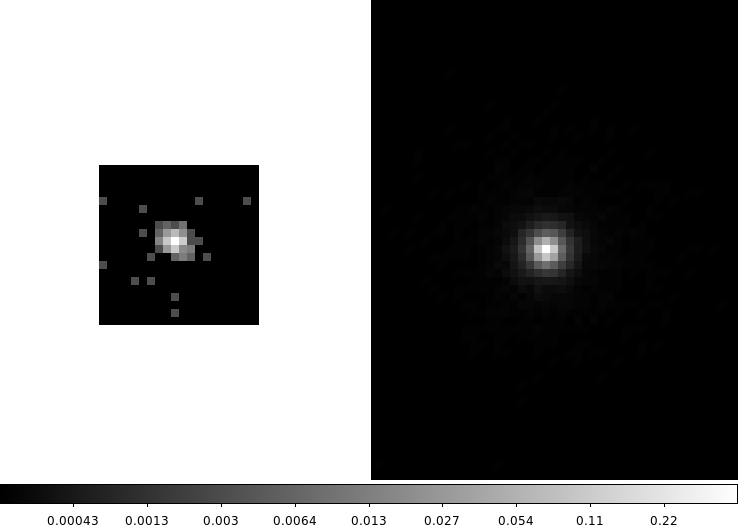

In [11]:
ds9 src_0001_broad_thresh.img -scale log \
    -zoom 8 \
    src_0001_broad.psf -scale log \
    -saveimage png ds9_02.png -quit

display < ds9_02.png

In [12]:
dmcopy "acisf04425_repro_evt2.fits[energy=500:7000]" broad.evt clob+

pset srcextent srcfile=broad.evt
pset srcextent outfile=extent.fits
pset srcextent psffile=src_0001_broad.psf 
pset srcextent regfile=src.reg
srcextent mode=h clob+


Results for Source 1

Source Observed Size: 0.44 " @ PA 46.40 deg at pixel coords 4048.0, 4044.9
    90% Confidence intervals: (0.40 -- 0.47) @ (INDEF -- INDEF)

PSF Observed Size:    0.75 " @ PA 48.01 deg at pixel coords 4048.5, 4045.5
    90% Confidence intervals: (0.69 -- 0.82) @ (INDEF -- INDEF)

Estimated Intrinsic Size: 0.00 " @ PA 0.00 deg
    90% Confidence intervals: (INDEF -- INDEF) @ (INDEF -- INDEF)

Source is not extended at 90% confidence


In [13]:
dmlist extent.fits"[cols EXTENT_FLAG, X, Y, MAJOR_AXIS, MINOR_AXIS, POS_ANGLE]" data,clean

#  EXTENT_FLAG X                    Y                    MAJOR_AXIS           MINOR_AXIS           POS_ANGLE
          0      4048.0247566804      4044.9448771639                    0                    0                    0


In [14]:
srcextent psffile= mode=h clob+ out=extent2.fits

Results for Source 1

Source Observed Size: 2.03 " @ PA 55.58 deg at pixel coords 4047.9, 4045.0
    90% Confidence intervals: (1.90 -- 2.16) @ (INDEF -- INDEF)




In [15]:
dmlist extent2.fits data,clean

#  FILENAME    X                    Y                    MJR_AXIS_RAW         MJR_AXIS_RAW_LO      MJR_AXIS_RAW_HI      MNR_AXIS_RAW         MNR_AXIS_RAW_LO      MNR_AXIS_RAW_HI      POS_ANGLE_RAW        POS_ANGLE_RAW_LO     POS_ANGLE_RAW_HI
 broad.evt        4047.9474296061      4045.0455681548         2.4860558673         2.3277650755         2.6443466591         1.4366557792         1.3451818168         1.5281297416        55.5805806328                  NaN                  NaN
